## What is Z-Score?
The Z-score tells you how many standard deviations a value is from the mean:

                            𝑧 = (x−μ)/σ 
x = data point
μ = mean
σ = standard deviation

## Rule of Thumb:

If ∣z∣>3, the value is typically considered an outlier (can vary depending on context).


## Remove Outliers Using Z-Score: 
1. Calculate the mean and standard deviation.
2. Compute the Z-score for each data point.
3. Filter out data points with ∣z∣>threshold (usually 3).

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
dataset = pd.read_csv("00_raw_data/height_weight.csv")
dataset.head()

,gender,height,weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   gender  10000 non-null  object 
 1   height  10000 non-null  float64
 2   weight  10000 non-null  float64
dtypes: float64(2), object(1)
memory usage: 234.5+ KB


In [4]:
dataset.describe()

,height,weight
count,10000.000000,10000.000000
mean,66.367560,161.440357
std,3.847528,32.108439
min,54.263133,64.700127
25%,63.505620,135.818051
50%,66.318070,161.212928
75%,69.174262,187.169525
max,78.998742,269.989699


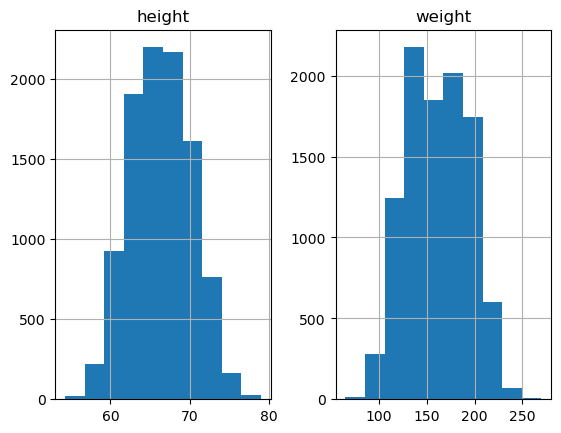

In [5]:
hist1=dataset.hist()

In [6]:
dataset.shape

(10000, 3)

In [7]:
dataset.isnull().sum()

gender    0
height    0
weight    0
dtype: int64

## Remove Using Outlier IQR

1. Calculate Q1 and Q3

    1. Q1 (25th percentile): Value below which 25% of the data falls.
    2. Q3 (75th percentile): Value below which 75% of the data falls.


3. Compute IQR
    IQR = Q3 - Q1

4. Determine the Outlier Boundaries
    Lower Bound = Q1 - 1.5 × IQR
    Upper Bound = Q3 + 1.5 × IQR

5. Filter the Data
    Keep only the values between the lower and upper bounds.

In [8]:
# Calculating the Q1 , Q3
Q1 = dataset.height.quantile(0.25)
Q3 = dataset.height.quantile(0.75)

In [9]:
Q1

np.float64(63.505620481218955)

In [10]:
Q3

np.float64(69.1742617268347)

In [11]:
#Calculating the IQR
IQR = Q3 - Q1
IQR

np.float64(5.668641245615746)

In [12]:
min_range = Q1 - (1.5 * IQR)
max_range = Q3 + (1.5 * IQR)
min_range , max_range 

(np.float64(55.00265861279534), np.float64(77.67722359525831))

In [13]:
dataset[(dataset.height >max_range) | (dataset.height < min_range)]

,gender,height,weight
994,Male,78.095867,255.690835
1317,Male,78.462053,227.342565
2014,Male,78.998742,269.989699
3285,Male,78.528210,253.889004
3757,Male,78.621374,245.733783
6624,Female,54.616858,71.393749
7294,Female,54.873728,78.606670
9285,Female,54.263133,64.700127


In [14]:
dataset1= dataset[(dataset.height < max_range) & (dataset.height > min_range)]

In [15]:
dataset1.sample(10)

,gender,height,weight
1866,Male,67.097418,187.098600
2077,Male,69.010642,177.586828
6060,Female,63.374143,138.024804
665,Male,65.973065,187.658379
8998,Female,68.642352,151.199121
4884,Male,64.585263,157.556612
2031,Male,70.575112,194.792540
2663,Male,65.594302,171.224027
5659,Female,68.127016,155.431007
3273,Male,70.482681,197.287686


In [16]:
Q1=dataset.weight.quantile(0.25)
Q3=dataset.weight.quantile(0.75)
IQR=Q3-Q1

In [17]:
IQR

np.float64(51.35147356318197)

In [18]:
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR

In [19]:
lower_limit,upper_limit

(np.float64(58.79084096072856), np.float64(264.19673521345646))

In [20]:
dataset[(dataset.weight > upper_limit) | (dataset.weight < lower_limit)]

,gender,height,weight
2014,Male,78.998742,269.989699


In [21]:
dataset2=dataset1[(dataset1.weight < upper_limit) & (dataset1.weight > lower_limit)]

In [22]:
dataset2

,gender,height,weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


🧠 Notes:
This method works well for univariate outliers (in one column).
For multivariate outliers, consider other methods like Isolation Forest or DBSCAN.